# Limit cycles of Triangulation strategy 

# import

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pyquaternion import Quaternion
from mpl_toolkits.mplot3d import Axes3D
import matplotlib
rc_fonts = {
    "font.family": "serif",
    "font.size": 20,
    'figure.figsize': (5, 3),
    "text.usetex": True
}
matplotlib.rcParams.update(rc_fonts)

import sys
sys.path.append("../General_Functions")

from Flow_functions import *

# Geometrical functions \& strategy

In [2]:
def Rotation(alpha, beta, gamma): # Calculate rotation 3 euler angles
    c1 = np.cos(alpha)
    s1 = np.sin(alpha)
    c2 = np.cos(beta)
    s2 = np.sin(beta)
    c3 = np.cos(gamma)
    s3 = np.sin(gamma)
    
    return np.array([
        [c1*c3 - c2*s1*s3, -c1*s3 - c2*c3*s1, s1*s2],
        [c3*s1 + c1*c2*s3, c1*c2*c3 - s1*s3, -c1*s2],
        [s2*s3,            c3*s2,             c2]
    ])

def Triangulation3D_A(n, d0, diff): # Triangulation strategy non-linear sign operation
    n_ = np.cross(d0, diff)
    d = np.cross(n, n_)
    sign = np.sign(np.dot(d0, d))
    target = sign * d0

    return target / np.linalg.norm(target)


def Triangulation3D_B(p1, d1, p2, d2): # Triangulation strategy skew lines nearest point
    # Information vector directions d1, d2
    # Sensor positions points p1, p2
    if np.allclose(d1, d2, rtol=1e-8) :
        return d1
    
    n = np.cross(d1,d2)
    n1 = np.cross(d1,n)
    n2 = np.cross(d2,n)
    
    if abs(np.dot(d1,d2)/(np.linalg.norm(d1)*np.linalg.norm(d2))) > 1 - 1e-8:
        return d1
    
    c1 = p1 + ((np.dot((p2-p1),n2)/np.dot(d1,n2)))*d1
    c2 = p2 + ((np.dot((p1-p2),n1)/np.dot(d2,n1)))*d2
    
    IntersectionPoint = 0.5*(c1+c2)
    TargetDirection = -(p1 + p2)/2 + IntersectionPoint
    return TargetDirection/np.linalg.norm(TargetDirection)


In [3]:
# Check gradient 

Flow = FlowStresslet  # FlowStokeslet, FlowStresslet, FlowQuadripole
Grad = StrainStresslet  #GradientStokeslet, GradientStresslet, GradientQuadripole
e = np.array([1, 0, 0])
eps = 1e-4

pos = np.random.rand(3)
dir1 = np.random.rand(3)
dir2 = np.random.rand(3)
dir1 /= np.linalg.norm(dir1)
dir2 /= np.linalg.norm(dir2)

gradapprox1 = np.dot((Flow(e, pos + eps * dir1) - Flow(e, pos)) / eps, dir2)
gradapprox2 = np.dot((Flow(e, pos + eps * dir2) - Flow(e, pos)) / eps, dir1)

print("grad sym approx", (gradapprox1 + gradapprox2) / 2)
print("grad sym exact", np.dot(np.dot(dir1, Grad(e, pos)), dir2))

grad sym approx 0.10887644628703336
grad sym exact 0.10887598265337609


In [4]:
# Numerical integration of triangulation strategy

def Evolution(n, b, t, AntennaeLength, AgentPosition, FlowGradient, e3, dt, twist):
    xs1 = AgentPosition + AntennaeLength*n
    xs2 = AgentPosition - AntennaeLength*n

    # Flow measured in the cope reference system It is basically the triangulation in 3D
    DirectionalGradient_s0 = np.dot(FlowGradient(e3, AgentPosition), n)
    DirectionalGradient_s1 = np.dot(FlowGradient(e3, xs1), n)
    DirectionalGradient_s2 = np.dot(FlowGradient(e3, xs2), n)
    
    TargetDirection = Triangulation3D_A(n, DirectionalGradient_s0, DirectionalGradient_s2 - DirectionalGradient_s1)
    #TargetDirection = Triangulation3D_B(xs1, DirectionalGradient_s1, xs2, DirectionalGradient_s2)

    AngularSpeed = dt * np.cross(t, TargetDirection)
    Norm = np.linalg.norm(AngularSpeed)

    Rotation = Quaternion(axis=AngularSpeed, angle=Norm) 
    new_n = Rotation.rotate(n)
    new_b = Rotation.rotate(b)
    new_t = Rotation.rotate(t)
    
    # NEW ROTATION AROUND t (it allows all trajectories to converge towards spirals)
    Rotation_t = Quaternion(axis=new_t, angle=twist * dt)
    new_n = Rotation_t.rotate(new_n)
    new_b = Rotation_t.rotate(new_b)
    
    new_n /= np.linalg.norm(new_n)
    new_b /= np.linalg.norm(new_b)
    new_t /= np.linalg.norm(new_t)
    
    return new_n, new_b, new_t
    

In [5]:
NTrials = 1 # Number of trajectories simulated
Duration = 1000 # Max step in time integration
twist = 0.2 # Imposed fixed roll
dt = 0.01 # Numberical integration timestep length
e3=np.array([1,0,0]) # Symmetry axis of the flow zxy space
AntennaeLength = .01 # Sensor - center of mass distance
Grad = StrainStresslet# GradientStokeslet, GradientStresslet, GradientQuadripole

# coordinates zxy
theta =  np.pi/8 # np.random.uniform(0,np.pi) # Azimutal angle
AgentPosition = np.array([np.cos(theta), np.sin(theta), 0]) # Spatial position of the agent

In [6]:
# Eigenvalues and eigenvector calculation of the Strain matrix 

# tensor gradient in coordinates zxy
G = Grad(e3, AgentPosition)
assert np.isclose(np.trace(G), 0), "gradient is not trace free"
#assert np.allclose(G, np.transpose(G)), "gradient is not symmetric"

# calculations of eigenvectors and relative eigenvalue a
vaps, veps = np.linalg.eig(G[:-1,:-1])
i_max = np.argmax(np.abs(vaps))
a = np.sum(vaps) / vaps[i_max] - 1

if np.abs(G[2,2]) > np.max(np.abs(vaps)):
    print("Greater eigenvalue is along e_phi")

# calculation of the trajectories of t as ellipses
ymax = np.cos(0.5 * np.arccos(a / (2 + a)))
zmax = np.cos(0.5 * np.arccos((a + 1) / (a - 1)))
print("gradient\n", G)
print("eigenvalues:", vaps, "   parameter a:", a)
print("ymax: ", ymax )
print("zmax: ", zmax)
# construction of ellipses with 
# n0 direction y (e_phi) 
# n1 eigenvector associated to eigenvalue a
# n2 main eigenvector (with eigenvalue 1)
n0 = np.array([0,0,1])
n2 = np.append(veps[:,i_max], 0) 
n2 *= np.sign(np.dot(n2, - AgentPosition))
n1 = np.cross(n2, n0)
angles = np.linspace(0, 2*np.pi, 36).reshape(1, 36)

circles1 = (
    n0[:,np.newaxis] * ymax * np.cos(angles) + 
    n1[:,np.newaxis] * zmax * np.sin(angles) + 
    n2[:,np.newaxis] * np.sqrt(1 - (ymax * np.cos(angles))**2 - (zmax * np.sin(angles))**2)
)


gradient
 [[-1.68566017 -2.40533009 -0.        ]
 [-2.40533009  0.125      -0.        ]
 [-0.         -0.          1.56066017]]
eigenvalues: [-3.35039534  1.78973516]    parameter a: -0.5341862629429757
ymax:  0.5637242951378547
zmax:  0.590075132940699


In [9]:
# Numerical realization

alphas, betas, gammas =  np.zeros((Duration, NTrials)), np.zeros((Duration, NTrials)), np.zeros((Duration, NTrials))
t0, t1, t2 = np.zeros((Duration, NTrials)), np.zeros((Duration, NTrials)), np.zeros((Duration, NTrials))
nz, ny, nx = np.zeros((Duration, NTrials)), np.zeros((Duration, NTrials)), np.zeros((Duration, NTrials))
bz, by, bx = np.zeros((Duration, NTrials)), np.zeros((Duration, NTrials)), np.zeros((Duration, NTrials))

EndDirections = np.zeros(NTrials)
MinProjection = np.zeros(NTrials)

for k in range(NTrials):
    alpha, beta, gamma = [np.pi/3, np.pi/7, np.pi/5] #(2 * np.random.rand(3) - 1) * np.pi
    RotationMatrix = Rotation(alpha, np.abs(beta), gamma)
    n = np.dot(RotationMatrix, n0)
    b = np.dot(RotationMatrix, n1)
    t = np.dot(RotationMatrix, n2)
    
    for time in range(Duration):
        n, b, t = Evolution(n, b, t, AntennaeLength, AgentPosition, Grad, e3, dt, twist)
        
        alphas[time,k] = np.arctan2(t[0], -t[1])
        betas[time,k]  = np.arccos(t[2])
        gammas[time,k] = np.arctan2(n[2], b[2])
        t0[time,k], t1[time,k], t2[time,k] = t
        nz[time,k], nx[time,k], ny[time,k] = n
        bz[time,k], bx[time,k], by[time,k] = b
    EndDirections[k] = np.dot(t,-AgentPosition)
    MinProjection[k] = np.dot(t,n2)

[ 0.37575434 -0.21694187  0.90096887] [0 0 1]


# Plot trajectory 
In the space of orientation of the swimming direction

C:\Users\Redaelli\AppData\Local\Temp\ipykernel_12760\2537450178.py:20: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(t1[:-1,:], t2[:-1,:], t0[:-1,:], c='#FFD166', s=5, marker='s', cmap='hsv', alpha=1)


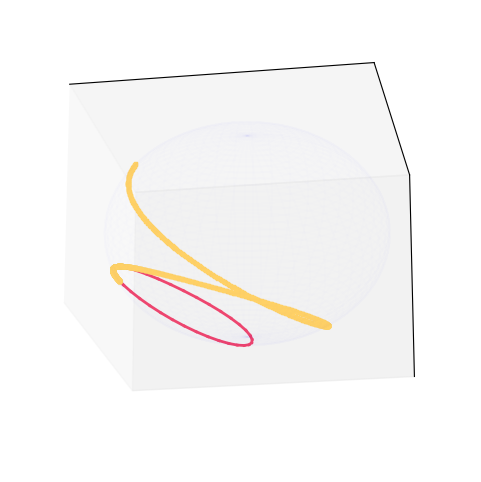

In [8]:
# %matplotlib qt

fig = plt.figure(figsize=(6, 6))

ax = fig.add_subplot(111, projection='3d')
# Plot t 3D
ax.scatter(t1[-1,:], t2[-1,:], t0[-1,:], c='blue', alpha=.02)

# Uncomment to plot gradient of color red - black along trajectory
# K  = 0
# NBlocks = 20
# s = int(Duration/NBlocks) # Segment length
# colors = np.linspace(0,1,NBlocks)
# colors = colors[::-1]
# for e, i in enumerate(range(0,Duration-s+1,s)):
#    ax.scatter(t1[i:i+s,:], t2[i:i+s,:], t0[i:i+s,:], color=(colors[e], 0, 0), marker='o',s = 5, alpha=.4)
#ax.scatter(t1[-1,K], t2[-1,K], t0[-1,K], c='black', s=100, marker='s', cmap='hsv', alpha=1)

# Plot trajectory
ax.scatter(t1[:-1,:], t2[:-1,:], t0[:-1,:], c='#FFD166', s=5, marker='s', cmap='hsv', alpha=1)
#ax.scatter(t1[-1,0], t2[-1,0], t0[-1,0], c='black', s=100, marker='s', cmap='hsv', alpha=1)


# Plot stable fixed points
for i in range(1,36):
    ax.plot([circles1[1,i-1], circles1[1,i]], \
             [circles1[2,i-1], circles1[2,i]], \
             [circles1[0,i-1], circles1[0,i]], \
            color= '#ef476f', linewidth = 2.0)
    
# Plot direction of the source 

# Uncomment to plot unstable fixed points
#for i in range(1,36):
#    ax.plot([-circles1[1,i-1], -circles1[1,i]], \
#             [-circles1[2,i-1], -circles1[2,i]], \
#             [-circles1[0,i-1], -circles1[0,i]], \
#            color= 'red', linewidth = 2.0, alpha)

ax.xaxis.labelpad= 20
ax.yaxis.labelpad= 30
ax.zaxis.labelpad= 30

# Draw sphere
u, v = np.mgrid[0:2*np.pi:200j, 0:np.pi:100j]
x = np.cos(u)*np.sin(v)
y = np.sin(u)*np.sin(v)
z = np.cos(v)
ax.plot_wireframe(x, y, z, color="blue", alpha = .005)


ax.set_xlim([-1,1])
ax.set_zlim([-1,1])
ax.set_ylim([-1,1])

#ax.set_xticks(np.arange(-1, 1.1, 0.5))
#ax.set_yticks(np.arange(-.5, 0.9, 0.5))
#ax.set_zticks(np.arange(-1, 1.1, 0.5))
ax.set_xticks([])
ax.set_yticks([])
ax.set_zticks([])

ax.view_init(elev= -20., azim=-80)
ax.dist = 12
ax.grid(False)
# Uncomment to save picture
fig.patch.set_visible(False)
plt.savefig("trajectory_.pdf", bbox_inches='tight')

# Fixed points representation
Plot cylunder drawn from eigenvector of strain matrix

In [9]:
# Function to draw a cylinder with axis along n0, basis n1,n2
def draw_cylinder(n2, n1, n0):
    #vector of the axis
    v = np.array([n2[1], n2[2], n2[0]])
    nn = np.array([n1[1], n1[2], n1[0]])
    nnn = np.array([n0[1], n0[2], n0[0]])
    #surface ranges over t from 0 to length of axis and 0 to 2*pi
    t = np.linspace(-1.1, 1.1, 100)
    theta = np.linspace(0, 2 * np.pi, 100)
    #use meshgrid to make 2d arrays
    t, theta = np.meshgrid(t, theta)
    #generate coordinates for surface
    Xc, Yc, Zc = [v[i] * t +  ymax *  np.cos(theta) * nnn[i] +  zmax *  np.sin(theta) * nn[i] for i in [0, 1, 2]]
    return Xc, Yc, Zc

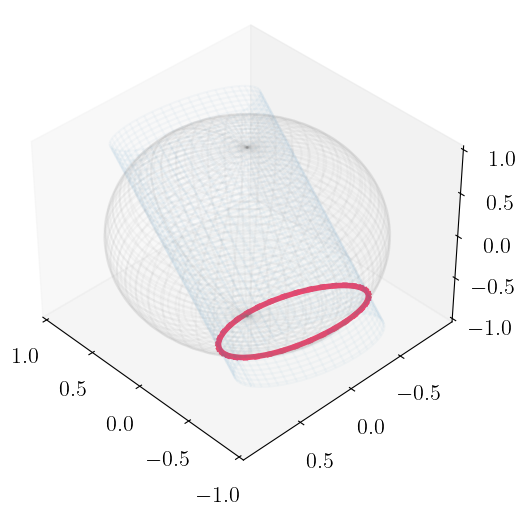

In [22]:
#%matplotlib qt
fig = plt.figure(figsize=(6, 6))
# Plot alpha, beta, gamma
ax2 = fig.add_subplot(111, projection='3d')
# Plot t 3D

ax2.scatter(t1[-1,:], t2[-1,:], t0[-1,:], c='blue', alpha=.02)
K  = 0
NBlocks = 20
s = int(Duration/NBlocks) # Segment length
colors = np.linspace(0,1,NBlocks)
colors = colors[::-1]
#for e, i in enumerate(range(0,Duration-s+1,s)):
    #ax2.scatter(t1[i:i+s,K], t2[i:i+s,K], t0[i:i+s,K], color=(colors[e], 0, 0), marker='o',s = 10, alpha=.25)
#ax2.scatter(t1[-1,K], t2[-1,K], t0[-1,K], c='black', s=100, marker='s', cmap='hsv', alpha=1)


for i in range(1,36):
    ax2.plot([circles1[1,i-1], circles1[1,i]], \
             [circles1[2,i-1], circles1[2,i]], \
             [circles1[0,i-1], circles1[0,i]], \
            color= '#ef476f', linewidth = 4.0)

ax2.xaxis.labelpad= 20
ax2.yaxis.labelpad= 30
ax2.zaxis.labelpad= 30

# Draw sphere
u, v = np.mgrid[0:2*np.pi:200j, 0:np.pi:100j]
x = np.cos(u)*np.sin(v)
y = np.sin(u)*np.sin(v)
z = np.cos(v)
ax2.plot_wireframe(x, y, z, color="grey", alpha = .05)

ax2.tick_params(axis='x', which='major', pad= 8, labelsize=16)
ax2.tick_params(axis='y', which='major', pad= 8, labelsize=16)
ax2.tick_params(axis='z', which='major', pad= 8, labelsize=16)

ax2.set_xlim([-1,1])
ax2.set_zlim([-1,1])
ax2.set_ylim([-1,1])

ax2.set_xticks(np.arange(-1, 1.1, 0.5))
ax2.set_yticks(np.arange(-.5, 0.9, 0.5))
ax2.set_zticks(np.arange(-1, 1.1, 0.5))

# Draw cylinder
Xc, Yc, Zc = draw_cylinder(n2, n1, n0)
ax2.plot_wireframe(Xc, Yc, Zc, alpha = 0.03)

ax2.view_init(elev= 38., azim=136)
ax2.grid(False)
plt.savefig("cylinder2_.pdf", bbox_inches='tight')